# Notebook miscelánea Tema 3 VA, Master IA UMU, curso 2025/26:
# Umbral de Otsu / Contornos / Transformaciones homográficas 2D / Wrappers en C

In [1]:
! wget -q https://ditec.um.es/~pedroe/plantilla-L-15x15.mp4 -O plantilla-L-15x15.mp4
# LINK ALTERNATIVO:
# wget -q https://univmurcia-my.sharepoint.com/:v:/g/personal/pedroe_um_es/EWRohU20TCJAuy0lGjGAO_QB__v2X8qX75gaj1kVPYl3rg?download=1 -O plantilla-L-15x15.mp4
! wget -q https://ditec.um.es/~pedroe/fotoplantilla.png -O fotoplantilla.png
# LINK ALTERNATIVO:
# wget -q https://univmurcia-my.sharepoint.com/:i:/g/personal/pedroe_um_es/Ee5Z6hgomyJLqq3gSC_GqPkB0N_aQRROsmDW9-mIiJksBw?e=Rxp9au -O fotoplantilla.png
! pip install mpld3

## Objetivos de este Notebook

* Ilustrar las ventajas de un método de umbralizado dinámico muy utilizado en visión por computador, el método de Otsu.
* Trabajar con un tipo de característica extraída mediante técnicas clásicas de visión por computador (un tipo de _hand engineered feature_) muy usado en cierto tipo de aplicaciones (p.e. realidad aumentada, que practicaremos ya al final del curso, partiendo de este mismo notebook): los contornos de imagen (listas de puntos 2D).
* Fijar los conceptos sobre los principales subgrupos de transformaciones homográficas del plano (transformaciones euclídeas, similares, afines y proyectivas 2D), aplicadas en este caso directamente sobre puntos pertenecientes a contornos en la imagen, en lugar de a imágenes completas.
* **Valor añadido:** Ejemplificar el interfaz de programación entre los lenguajes Python y C, que permite delegar determinadas tareas intensivas en cómputo en este último lenguaje, con el consiguiente incremento de la eficiencia computacional.

## Imports necesarios

In [2]:
# Generales (OpenCV, numpy, matplotlib):
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mpld3
mpld3.enable_notebook()  # Interactividad matplotlib para todo el notebook

# Ipywidgets:
from ipywidgets import IntSlider, FloatSlider, Checkbox, interact, fixed

# ctypes (interfaz con C)
from ctypes import Structure, pointer, POINTER, c_float, c_int, cast
from numpy.ctypeslib import load_library, ndpointer

## Función de procesamiento principal

La función `processing` que definiremos en esta sección recibirá una imagen de entrada, sobre la que realizará una operación de umbralizado y una posterior extracción de contornos, y de los cuales se devolverá sólo el de longitud más larga.

Además de la imagen de entrada, la función recibirá (como parámetros) las siguiente **funciones** adicionales:
1. Una función `comp_histo_XXX` que, a partir de la imagen de entrada en niveles de gris, ha de computar su histograma como un `np.array` de tipo entero.
2. Una función `comp_threshold_XXX` que, a partir de un histograma, o bien directamente a partir de toda la imagen, computa un umbral entero para la imagen (en el rango [0,255]).
3. Una función `comp_thresholded_image_XXX` que, a partir de la imagen de entrada, y un umbral entero, devuelve la correspondiente imagen umbralizada (binaria).
4. Una función `comp_longest_cont_XXX` que, a partir de una imagen binarizada, devuelve el contorno más largo de la imagen (como secuencia de coordenadas de píxeles 4-conectados en la misma).

In [3]:
def comp_histo_cv2(inimg):
  # Cómputo de histograma usando OpenCV:
  hist = cv2.calcHist([inimg], [0], None, [256], [0, 256])
  return hist[:,0]   # Flatten de (256,1) a (256,)

In [4]:
def comp_threshold_mean(hist, inimg):
  # Umbral ingenuo: simple media del histograma (Nota: no se usa para nada la imagen de entrada).
  thresh = np.dot(np.arange(256), hist) / np.sum(hist)
  return int(thresh)

In [5]:
def comp_threshold_Otsu(hist, inimg):
  # Umbral Otsu alternativo: calculado internamente por función cv2.threshold de la OpenCV, con la opción cv2.THRESH_OTSU
  # (Nota: no se usa en este caso directamente el histograma, sino que la OpenCV lo hace indirectamente a traveś de la imagen de entrada)
  thresh, _ = cv2.threshold(inimg, thresh=100, maxval=255, type=cv2.THRESH_OTSU) # Parámetro thres *no usado en realidad*
  return int(thresh)

In [6]:
def comp_thresholded_image_cv2(inimg, thresh):
  # Umbralizado de la imagen:
  _, thrimg = cv2.threshold(inimg, thresh, 255, cv2.THRESH_BINARY)
  return thrimg

In [7]:
def comp_longest_cont_cv2(thrimg):
  # Contornos calculados por la OpenCV:
  cnts, _ = cv2.findContours(thrimg.copy(), cv2.RETR_LIST,cv2.CHAIN_APPROX_SIMPLE)

  # Devolvemos sólo el primero de los contornos (por longitud):
  sortedcnts = sorted(cnts, key=lambda x: x.shape[0])
  cnt = sortedcnts[::-1][0]
  return cnt

In [8]:
def processing(inimg, comp_histo, comp_threshold, comp_thresholded_image, comp_longest_cont):
  # Llamada a las cuatro funciones pasadas como parámetro:
  hist = comp_histo(inimg)
  thresh = comp_threshold(hist, inimg)
  thrimg = comp_thresholded_image(inimg,thresh)
  cnt = comp_longest_cont(thrimg)

  # Devolución de tupla con todos los resultados a mostrar:
  return inimg, hist, thresh, thrimg, cnt

La definición de la anterior función, a la que se le pasan como parámetros otras funciones, nos permitirá comparar posteriormente distintas implementaciones de las mismas.

## Visualización interactiva de resultados:

In [9]:
def process_video(videofile, nframes, comp_histo, comp_threshold, comp_thresholded_image, comp_longest_cont):
  videoreader = cv2.VideoCapture(videofile)
  i, results = 0, []
  while True:
    (grabbed, img) = videoreader.read()
    if not grabbed or i==nframes: # Sólo número de frames solicitados
      break
    else:
      # Realizamos el procesamiento:
      imggray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
      inimg, hist, thresh, thrimg, cnt = processing(imggray, comp_histo, comp_threshold, comp_thresholded_image, comp_longest_cont)
      # Añadimos ahora a la lista de resultados, la imagen resultante, junto con el resto de resultados
      # a los que queramos tener acceso a la hora de visualizar (en este caso, el histograma, el umbral calculado, y el contorno principal)
      results.append((inimg, hist, thresh, thrimg, cnt))
    # Siguiente frame:
    i += 1
  # Devolvemos todos los resultados del procesamiento frame a frame:
  return results

In [10]:
def plot_image(results, framepos, tx, ty, bin_gray):
  # Lectura de variables de salida del procesamiento para el frame actual:
  inimg, hist, thresh, thrimg, cnt = results[framepos]
  rows, cols = inimg.shape

  histprob = hist.astype(float)/(cols*rows)

  fig, (axescanvas,axeshisto) = plt.subplots(1,2,figsize=(12.,4.))
  if bin_gray:
    axescanvas.imshow(inimg, cmap='gray')
  else:
    axescanvas.imshow(thrimg, cmap='gray')

  axescanvas.set_xlim([0, cols])
  axescanvas.set_ylim([rows, 0])
  axescanvas.set_aspect(1.0)

  axeshisto.set_xlim([0, 255])
  axeshisto.set_ylim([0, np.max(histprob)])

  axeshisto.plot(range(256), histprob, 'g')
  axeshisto.plot([thresh, thresh], [0, np.max(histprob)/2], 'r')

  # Aplicación de una sencilla transformación de traslación a los puntos del contorno principal:
  transmat = np.array([[1.0, 0.0, tx],
                       [0.0, 1.0, ty],
                       [0.0, 0.0, 1.0]])


  # Puntos del contorno como matriz (puntos = vectores columna):
  mp = np.concatenate((cnt[:, 0, :],
                        np.ones((cnt.shape[0], 1))),
                      axis=1).T
  # Transformación simultánea de todos los puntos:
  mpt = np.dot(transmat, mp)

  linesshown, = axescanvas.plot(mpt[0]/mpt[2], mpt[1]/mpt[2])

  plt.show()

Procesamos ahora 150 frames del vídeo utilizando las funciones básicas definidas más arriba (`comp_histo_cv2`, `comp_threshold_mean`, `comp_thresholded_image_cv2`, `comp_longest_cont_cv2`):

In [11]:
results = process_video("plantilla-L-15x15.mp4", 150, comp_histo_cv2, comp_threshold_mean, comp_thresholded_image_cv2, comp_longest_cont_cv2);

In [12]:
rows, cols = results[0][0].shape
interact(plot_image,
         results=fixed(results),
         framepos=IntSlider(value=0,min=0,max=len(results)-1,orientation='horizontal', continuous_update=False),
         tx=FloatSlider(value=0,min=-cols/2,max=cols/2,orientation='horizontal', continuous_update=False),
         ty=FloatSlider(value=0,min=-rows/2,max=rows/2,orientation='horizontal', continuous_update=False),
         bin_gray=Checkbox(value=False,description='binary/gray', continuous_update=False)
         );

interactive(children=(IntSlider(value=0, continuous_update=False, description='framepos', max=149), FloatSlide…

Comprobamos que la posición del umbral (línea vertical roja en el histograma verde) nos genera una figura principal (negra en la imagen umbralizada) incorrecta en muchos frames, ya que dicha media puede "cortar" la moda derecha del histograma (correspondiente al fondo claro), en lugar de colocarse correctamente entre ambas modas (lo que separaría mejor las mismas).

## Método de Otsu

El umbral utilizado en la solución anterior (media de la distribución de los valores de gris) es demasiado ingenuo, como se puede comprobar en los resultados.

Alternativamente, el método de Otsu intenta calcular un umbral óptimo $\tau_{opt}$ con el que binarizar una imagen de grises de entrada a partir de su histograma $h(i)$, con $i=0\dots 255$. Para ello, el método realiza los siguientes pasos:

1. Para todos los posibles valores de $\tau$ entre $0$ y $256$, se computa el valor de la función de mérito $\sigma_w^2(\tau) = \omega_1(\tau)\sigma_1^2(\tau) + \omega_2(\tau)\sigma_2^2(\tau)$, donde:

  * $\omega_i(\tau)$, con $i=1,2$, son las probabilidades a priori de las clases 1 (píxeles por debajo del umbral $\tau$) y 2 (píxeles por encima o igual al umbral $\tau$). Dichas probabilidades se pueden calcular a partir del histograma mediante las siguientes fórmulas:
      
      $$\omega_1(\tau) = \frac{\sum_{j=0}^{\tau-1} h(j)}{\sum_{j=0}^{255} h(j)}$$

      $$\omega_2(\tau) = \frac{\sum_{j=\tau}^{255} h(j)}{\sum_{j=0}^{255} h(j)}$$
  * $\sigma_i^2(\tau)$, con $i=1,2$, son las varianzas respectivas de las clases 1 y 2. De nuevo dichos valores se calculan fácilmente a partir del histograma usando las fórmulas:

      $$\sigma_i^2(\tau) = \bar{(\mu_i^2)}-(\bar{\mu}_i^2)$$

    siendo
      
      $$\bar{\mu_1} = \frac{\sum_{j=0}^{\tau-1} j \cdot h(j)}{\sum_{j=0}^{\tau-1} h(j)}$$

    y

      $$\bar{\mu_2} = \frac{\sum_{j=\tau}^{255} j \cdot h(j)}{\sum_{j=\tau}^{255} h(j)}$$

    las medias de las respectivas clases, y

      $$\bar{(\mu_1^2)} = \frac{\sum_{j=0}^{\tau-1} j^2 \cdot h(j)}{\sum_{j=0}^{\tau-1} h(j)}$$

    y

      $$\bar{(\mu_2^2)} = \frac{\sum_{j=\tau}^{255} j^2 \cdot h(j)}{\sum_{j=\tau}^{255} h(j)}$$

    las medias de los valores al cuadrado de las respectivas clases.

2. Se selecciona el umbral óptimo $\tau_{opt} = \underset{\tau\in[0,256]}{\operatorname{argmin}}\sigma_w^2(\tau)$, es decir, el valor de $\tau$ que minimiza el valor de la función de mérito anterior.

El procedimiento anterior puede ser optimizado de forma relativamente sencilla. Por ejemplo, se puede demostrar que, equivalentemente, el umbral de Otsu se puede calcular como el que maximiza la varianza interclase según la fórmula siguiente:

  $$\sigma_b^2(\tau) = \omega_1(\tau)\omega_2(\tau)(\mu_1(\tau) - \mu_2(\tau))^2$$

Una posible implementación alternativa que usa esta idea y evita la necesidad de bucles `for` anidados puede consultarse en la entrada correspondiente al _Otsu's method_ en la [Wikipedia](https://en.wikipedia.org/wiki/Otsu%27s_method).


En todo caso, la OpenCV incluye ya directamente una función que umbraliza la imagen con el umbral dinámico de Otsu, calculado internamente de la manera comentada:

El umbral utilizado (computado mediante el método de Otsu) ha sido:  127


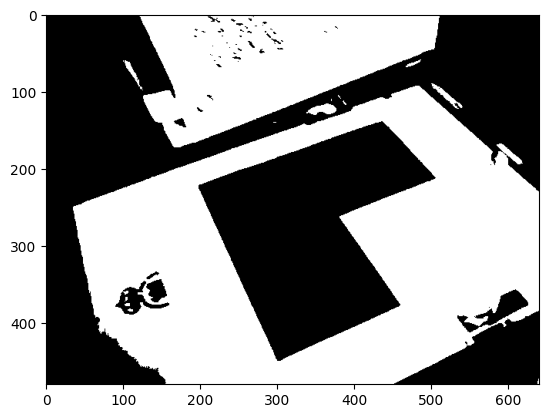

In [13]:
inimg = cv2.imread("fotoplantilla.png")
imggray = cv2.cvtColor(inimg, cv2.COLOR_BGR2GRAY)
val, thrimg = cv2.threshold(imggray, thresh=100, maxval=255, type=cv2.THRESH_OTSU)
print("El umbral utilizado (computado mediante el método de Otsu) ha sido: ", int(val))
plt.imshow(thrimg, cmap="gray");

Si volvemos a procesar el vídeo usando en este caso el umbral de Otsu (mediante la función `comp_threshold_Otsu`), vemos que la plantilla se detecta ahora en prácticamente la totalidad de los frames correctamente (al contrario de lo que pasaba con el ingenuo umbral de la media del histograma). Obsérvese en particular la posición del umbral (línea vertical roja) en el gráfico del histograma (en verde) para cada frame:

In [14]:
results = process_video("plantilla-L-15x15.mp4", 150, comp_histo_cv2, comp_threshold_Otsu, comp_thresholded_image_cv2, comp_longest_cont_cv2)
rows, cols = results[0][0].shape
interact(plot_image,
         results=fixed(results),
         framepos=IntSlider(value=0,min=0,max=len(results)-1,orientation='horizontal', continuous_update=False),
         tx=FloatSlider(value=0,min=-cols/2,max=cols/2,orientation='horizontal', continuous_update=False),
         ty=FloatSlider(value=0,min=-rows/2,max=rows/2,orientation='horizontal', continuous_update=False),
         bin_gray=Checkbox(value=False,description='binary/gray', continuous_update=False)
         );

interactive(children=(IntSlider(value=0, continuous_update=False, description='framepos', max=149), FloatSlide…

No obstante, y aunque la sencilla heurística de quedarnos simplemente con el contorno más largo funciona bien en la mayoría de frames para capturar los bordes de la plantilla, en el vídeo se aprecia que dicho método es también demasiado ingenuo para una aplicación real, ya que en ciertos frames puede fallar (véanse, por ejemplo el último frame, desplazando el slide _framepos_ a la posición 149)

## Transformaciones homográficas del plano aplicadas a _hand engineered features_ extraidas de la imagen (puntos, contornos, etc.)

Como ya sabemos, dado un punto cualquiera en un plano, su posición $(x,y)$ puede ser transformada proyectivamente aplicándole una sencilla multiplicación por una matriz denotada como $\mathtt{H}_{3\times 3}$, conocida como _matriz de transformación homográfica_. Para ello, dichas coordenadas han de ser previamente "_homogeneizadas_" añadiéndoles un 1 como tercera coordenada, para transformarlas en vectores tridimensionales $v_{in}=(x,y,1)$. Las coordenadas 2D transformadas finales se obtienen entonces a partir del vector resultado de la multiplicación $v_{out} = \mathtt{H} \cdot v_{in}$ simplemente dividiendo las dos primeras coordenadas de $v_{out}$ por su tercera coordenada ("_deshomogeneización_").

   Una posible forma de descomponer $\mathtt{H}_{3 \times 3}$ puede ser la siguiente:

  $$\mathtt{H} = \mathtt{K} \cdot \mathtt{S} \cdot \mathtt{A} \cdot \mathtt{P} \cdot \mathtt{K}^{-1} $$

   donde:

  $$
    (\mathtt{K} , \mathtt{S} , \mathtt{A} , \mathtt{P}) =  
  $$
    
  $$
    (
    \begin{pmatrix}
      s & 0 & w/2 \\
      0 & s & h/2 \\
      0 & 0 & 1
    \end{pmatrix} ,
    \begin{pmatrix}
      s_x\cos(\alpha) & -s_x\sin(\alpha) & t_x \\
      s_y\sin(\alpha) &  s_y\cos(\alpha) & t_y \\
      0               & 0                & 1
    \end{pmatrix} ,
    \begin{pmatrix}
      1 & a & 0 \\
      0 & 1 & 0 \\
      0 & 0 & 1
    \end{pmatrix} ,
    \begin{pmatrix}
      1   & 0 & 0 \\
      0   & 1 & 0 \\
      p_1 & p_2 & 1
    \end{pmatrix}
    )
  $$

   Los parámetros de la matriz $\mathtt{K}_{3 \times 3}$ se suelen usar para realizar un escalado y centrado previo de los puntos a transformar. Si, por ejemplo, los puntos a transformar provienen de un contorno obtenido de la imagen de entrada, unos valores iniciales razonables podrían ser $w=$ _ancho de la imagen_ y $h=$ _alto de la imagen_, y $s$ un valor aproximadamente del tamaño de, por ejemplo, el eje mayor del contorno a transformar (aunque, por supuesto, esto depende totalmente de la escala y posición iniciales de los puntos de entrada).

   En cuanto al resto de parámetros para las matrices $\mathtt{S}_{3 \times 3}$, $\mathtt{A}_{3 \times 3}$ y $\mathtt{P}_{3 \times 3}$, se corresponden con los siguientes modos de transformación:

  * $\alpha$ es el ángulo de rotación,
	* $(t_x,t_y)$ es la traslación en los ejes X e Y,
	* $(s_x,s_y)$ son los escalados en dichos ejes,
	* $a$ es el _skew_ (sesgo), y
	* $(p_1,p_2)$ son los parámetros que consiguen el efecto de perspectiva.


**Ejercicio:** Se deja como ejercicio sencillo para el lector la adaptación del código de las funciones `plot_image` e `interact` anteriores, para añadir los parámetros $\alpha$, $s_x$, $s_y$, $a$, $p_1$ y $p_2$ a los ya existentes $t_x$ y $t_y$ en las mencionadas funciones, y permitir así al usuario visualizar interactivamente los efectos de dichos parámetros sobre la correspondiente transformación homográfica. Al aplicarse sólo sobre el principal contorno obtenido de la imagen, esta transformación es bastante más eficiente que la de la imagen completa, que probamos ya en anteriores sesiones de prácticas.


## _Wrappers_ de C para Python: ejemplo de histograma en C

En lo que sigue se muestra un sencillo ejemplo de cómo podemos compilar una librería de funciones en C para, posteriormente, acceder a ellas desde python.

En primer lugar, creamos un archivo de texto plano con el _makefile_ necesario para realizar la compilación. El archivo resultado (en este caso `Makefile1`) quedará convenientemente salvado en la nube de Colab.

In [15]:
makefilestr = '''
all: libhisto.so.1.0.1 libhisto.so

libhisto.so.1.0.1: histo.c histo.h
	gcc -Wall -c -fPIC histo.c
	gcc -shared -Wl,-soname,libhisto.so.1 -o libhisto.so.1.0.1 histo.o

libhisto.so: libhisto.so.1.0.1
	ln -s libhisto.so.1.0.1 libhisto.so

clean:
	rm -f libhisto.so.1.0.1 libhisto.so histo.o *~
'''
with open('Makefile1', 'w') as writer:
  writer.write(makefilestr)

A continuación, hacemos lo propio con los archivos fuente en C (.h y .c) de las funciones de nuestra librería. En este caso, se trata simplemente de un cálculo sencillo del histograma a partir del recorrido de la imagen en memoria, a la que se accede conociendo el puntero a la zona de memoria donde comienza, y su tamaño en filas y columnas.

Obsérvese también que el histograma computado necesita un espacio para almacenarse, que es convenientemente reservado por la propia función `get_histogram_c`, mediante la correspondiente reserva de memoria dinámica. Ello hace que, además de dicha función, haga falta también una función adicional para liberar dicha memoria después. Ese es el cometido de la función `free_mem_histogram_c`.

In [16]:
histohstr = '''
typedef struct {
    int *hist;
} THistogram;

int get_histogram_c(const unsigned char *imgin, int cols, int rows, THistogram *histogram);

void free_mem_histogram_c(THistogram *histogram);
'''
with open('histo.h', 'w') as writer:
  writer.write(histohstr)

In [17]:
histoccstr = '''
#include <stdlib.h>
#include "histo.h"

int get_histogram_c(const unsigned char *imgin, int cols, int rows, THistogram *histogram)
{
    histogram->hist = (int*) malloc(256*sizeof(int));
    for (int i=0; i<256;i++) {
        histogram->hist[i] = 0;
    }
    for(int i=0; i<rows; i++) {
        for(int j=0; j<cols; j++) {
            histogram->hist[imgin[i*cols+j]]++;
        }
    }
    return 0;
}

void free_mem_histogram_c(THistogram *histogram)
{
    free(histogram->hist);
}
'''
with open('histo.c', 'w') as writer:
  writer.write(histoccstr)

La compilación de la librería la podemos realizar entonces con un sencillo comando `make`:

In [18]:
!make -f Makefile1

gcc -Wall -c -fPIC histo.c
gcc -shared -Wl,-soname,libhisto.so.1 -o libhisto.so.1.0.1 histo.o


Una vez disponible la funcionalidad en una librería convenientemente compilada, nos queda diseñar el interfaz con python. Para ello, se usa la librería ctypes, tal y como se ilustra a continuación.

En general, los pasos que habrá que hacer para ello serán:

1. Si la librería maneja estructuras (en nuestro ejemplo, `THistogram`), crear una clase de python para que haga de _wrapper_ de aquella(s). En nuestro caso, la estructura es muy simple y sólo tiene un puntero a un array de enteros. Se pueden consultar ejemplos algo más completos [aquí](https://docs.python.org/3/library/ctypes.html).

2. Declarar los prototipos de las funciones de la librería, mediante la especificación de los argumentos en el campo `.argtypes`, y, en su caso, sus posibles valores devueltos, en el campo `.restype`.

3. Finalmente, crear funciones python (que serán las que queden expuestas al usuario final del _wrapper_), que realicen la adaptación de los datos de entrada, la llamada a la función de la librería, y la adaptación de los datos de salida de la función a los tipos de datos nativos de python que se consideren más adecuados. En nuestro caso, serán habitualmente arrays de numpy (como en el ejemplo), aunque, adicionalmente, y dependiendo de la función adaptada, podrían también usarse listas, diccionarios, tuplas, etc.

**Nota**: Un procedimiento similar al aquí descrito es el que emplean en su implementación la mayoría de librerías de cómputo científico de python, como la propia `numpy`, `pandas`, `OpenCV`, etc.

In [19]:
# Wrapper(s) para estructura(s) de C:
class THistogram(Structure):
  _fields_ = [("hist", POINTER(c_int))]

# Cargar librería dinámica compilada desde C:
libhistoC = load_library('libhisto.so', './')

#### Prototipos de funciones:
## 1. Función get_histogram_c:
libhistoC.get_histogram_c.argtypes = [
    # Argumentos
    ndpointer(dtype=np.uint8, ndim=2, flags='C'),
    c_int,
    c_int,
    POINTER(THistogram)]
libhistoC.get_histogram_c.restype = c_int # Tipo de valor devuelto

## 2. Función free_mem_histogram_c:
libhistoC.free_mem_histogram_c.argtypes = [
    POINTER(THistogram)]
# (Devuelve void, así que no es necesario añadir restype).

# Wrapper Python para llamar a la función en C y recoger los resultados
# cómodamente:
def comp_histo_C(img):
    # Preparamos parámetros para pasar a la función de la librería:
    rows, cols = img.shape
    histogramC = THistogram()
    # Hacemos la llamada (primera función de la librería):
    libhistoC.get_histogram_c(img, cols, rows, pointer(histogramC))
    # Recuperamos los resultados en un array:
    histogram = np.ctypeslib.as_array(
                     cast(histogramC.hist, POINTER(c_int)),
                     shape=(256,))
    # Generamos una copia ...
    histogram = np.copy(histogram)
    # ... ya que la memoria original reservada en C la liberamos aquí
    # (segunda función de la librería):
    libhistoC.free_mem_histogram_c(pointer(histogramC))
    # Finalmente devolvemos el np.array de tipo int creado:
    return histogram

A partir de ese momento, nuestra nueva función de cómputo del histograma en C se puede utilizar desde python, al igual que hacemos con cualquier otra función de las librerías numpy, opencv, etc.

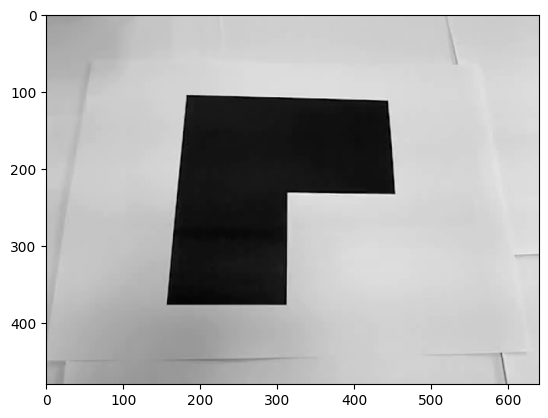

In [20]:
img1 = results[0][0]
plt.imshow(img1,cmap='gray');

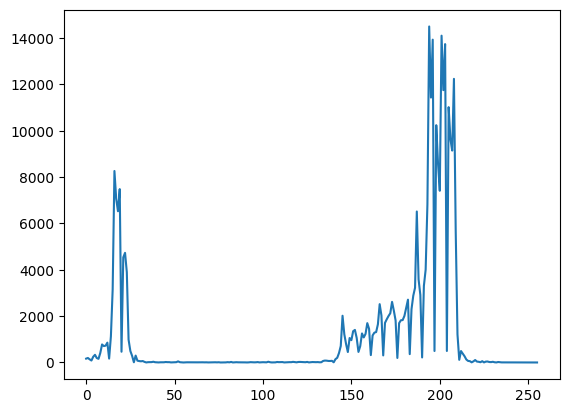

In [21]:
hist = comp_histo_C(img1)
plt.plot(hist);

Ilustramos aquí cómo, utilizando la misma función `process_video` anterior, y pasando como parámetros las funciones `comp_histo_cv2` y `comp_histo_c`, podemos comparar su influencia en el rendimiento global de la aplicación (midiendo el tiempo que tardan en realizar todo el procesamiento deseado sobre el vídeo de entrada):

In [22]:
import time

dict_results = {}
for i,comp_histo_fun in enumerate([comp_histo_cv2, comp_histo_C]):
  start = time.time()
  NFRAMES = 500
  dict_results[comp_histo_fun.__name__] = \
    process_video("plantilla-L-15x15.mp4", NFRAMES, comp_histo_fun, comp_threshold_mean, comp_thresholded_image_cv2, comp_longest_cont_cv2)
  end = time.time()
  print(f"Elapsed time ({comp_histo_fun.__name__}): {end-start:2.3f} seconds for {NFRAMES} frames ({NFRAMES/(end-start):2.3f} fps).")


Elapsed time (comp_histo_cv2): 5.292 seconds for 500 frames (94.474 fps).
Elapsed time (comp_histo_C): 3.504 seconds for 500 frames (142.676 fps).


En este caso, los rendimientos son similares, ya que por supuesto la librería OpenCV está también programada en C++, con el correspondiente wrapper de python, para evitar el cuello de botella que supondría intentar procesar la imagen directamente con bucles de python. Otro buen ejercicio ilustrativo sería programar directamente en python, con dichos bucles, un cómputo del histograma, para ver cómo el rendimiento caería de forma muy notable.

Por supuesto, podemos comparar gráficamente que los resultados coinciden:

In [23]:
interact(plot_image,
         results=fixed(dict_results['comp_histo_cv2']),
         framepos=IntSlider(value=0,min=0,max=len(results)-1,orientation='horizontal', continuous_update=False),
         tx=fixed(0),  # No interactuar
         ty=fixed(0),  # No interactuar
         bin_gray=fixed(True)
         );

interactive(children=(IntSlider(value=0, continuous_update=False, description='framepos', max=149), Output()),…

In [24]:
interact(plot_image,
         results=fixed(dict_results['comp_histo_C']),
         framepos=IntSlider(value=0,min=0,max=len(results)-1,orientation='horizontal', continuous_update=False),
         tx=fixed(0),  # No interactuar
         ty=fixed(0),  # No interactuar
         bin_gray=fixed(True)
         );

interactive(children=(IntSlider(value=0, continuous_update=False, description='framepos', max=149), Output()),…

## Notas y referencias adicionales

* Si se desean grabar vídeos propios de la plantilla (que, como continuación de esta práctica, se podrían emplearán en prácticas posteriores relacionadas con la realidad aumentada, ya en BT5), se puede encontrar en el archivo `plantilla-L-15x15.pdf` disponible en el aula virtual.

* Tutorial histogramas OpenCV [aquí](https://docs.opencv.org/master/d1/db7/tutorial_py_histogram_begins.html).

* Tutorial contornos OpenCV [aquí](https://docs.opencv.org/master/d4/d73/tutorial_py_contours_begin.html).

* Tutorial sobre descriptores de contornos en OpenCV [aquí](https://docs.opencv.org/master/d3/dc0/group__imgproc__shape.html).

* Entrada wikipedia método de aproximación poligonal de Douglas Pecker [aquí](http://en.wikipedia.org/wiki/Ramer\%E2\%80\%93Douglas\%E2\%80\%93Peucker_algorithm).

* Entrada wikipedia método de Otsu [aquí](http://en.wikipedia.org/wiki/Otsu\%27s_method).


## Apéndice: Posible esqueleto para programación de contornos en C (avanzado)

Lo incluido en este apartado será sólo de interés si se desea estudiar un ejemplo algo más completo de interacción entre C y Python. Por ejemplo, si se quisiera implementar una función que, a partir de una imagen binarizada, extrajera contornos de la misma (implementando un autómata de recorrido de contornos, p.e. el [algoritmo de Moore-neighbourhood](https://www.codeproject.com/Articles/1105045/Tracing-Boundary-in-D-Image-Using-Moore-Neighborho)), un posible esqueleto sería el expuesto a continuación.

In [25]:
makefilestr = '''
all: libowncsrc.so.1.0.1 libowncsrc.so

libowncsrc.so.1.0.1: owncsrc.c owncsrc.h
	gcc -Wall -c -fPIC owncsrc.c
	gcc -shared -Wl,-soname,libowncsrc.so.1 -o libowncsrc.so.1.0.1 owncsrc.o

libowncsrc.so: libowncsrc.so.1.0.1
	ln -s libowncsrc.so.1.0.1 libowncsrc.so

clean:
	rm -f libowncsrc.so.1.0.1 libowncsrc.so owncsrc.o *~
'''
with open('Makefile', 'w') as writer:
  writer.write(makefilestr)

In [26]:
owncsrchstr = '''
typedef struct {
    // Arrays para datos de contornos (coordenadas x e y separadas):
    float *x, *y;
    // Array para tamaños de los contornos, e índices de comienzo de cada contorno:
    int *cs, *ccs;
    // Número total de puntos, y número total de contornos:
    int pn, cn;
} TContours;

int get_contours(const unsigned char *imgin, int cols, int rows, TContours *contours);

void free_mem_contours(TContours *contours);
'''
with open('owncsrc.h', 'w') as writer:
  writer.write(owncsrchstr)

In [27]:
owncsrccstr = '''
#include <stdlib.h>
#include "owncsrc.h"

// Función de ejemplo que devuelve una lista de contornos en una estructura TContours:
int get_contours(const unsigned char *imgin, int cols, int rows, TContours *contours)
{
    // En este ejemplo simplemente se devuelven dos contornos, el primero de 6 puntos (en forma de
    // plantilla en L), y el segundo de 4 (en forma de cuadrado en el que el último vértice ha sido
    // sustituido por la esquina inferior derecha de la imagen), que dependen de la imagen de
    // entrada simplemente sumando a las esquinas fijadas el valor medio de la imagen de gris
    // (sólo para demostrar también de forma sencilla la lectura de los píxeles de la imagen de entrada):
    float x[10] = {100., 200., 200., 150., 150., 100., 200., 300., cols, 200};
    float y[10] = {100., 100., 150., 150., 200., 200., 200., 200., rows, 300};
    int cs[2] = {6, 4}, ccs[2] = {0, 6};
    int pn = 10, cn = 2;
    int i, j;

    float mean = 0.0;
    for(i=0; i<rows; i++)
        for(j=0; j<cols; j++)
            mean += imgin[i*cols+j];
    mean /= (cols*rows);

    contours->x = (float *) malloc(pn*sizeof(float));
    contours->y = (float *) malloc(pn*sizeof(float));
    for(i=0; i<pn; i++) {
        contours->x[i] = x[i] + (i!=pn-2?mean:0.0);
        contours->y[i] = y[i] + (i!=pn-2?mean:0.0);
    }
    contours->cs = (int *) malloc(cn*sizeof(int));
    contours->ccs = (int *) malloc(cn*sizeof(int));
    for(j=0; j<cn; j++) {
        contours->cs[j] = cs[j];
        contours->ccs[j] = ccs[j];
    }
    contours->pn = pn;
    contours->cn = cn;

    return 0;
}


// Liberar memoria dinámica asociada a estructura TContours:
void free_mem_contours(TContours *contours)
{
    free(contours->x);
    free(contours->y);
    free(contours->cs);
    free(contours->ccs);
}
'''
with open('owncsrc.c', 'w') as writer:
  writer.write(owncsrccstr)

In [28]:
!make

gcc -Wall -c -fPIC owncsrc.c
gcc -shared -Wl,-soname,libowncsrc.so.1 -o libowncsrc.so.1.0.1 owncsrc.o


In [29]:
# Wrapper(s) para estructura(s) de C:
class TContours(Structure):
    _fields_ = [("x", POINTER(c_float)), ("y", POINTER(c_float)),
                ("cs", POINTER(c_int)), ("ccs", POINTER(c_int)),
                ("pn", c_int), ("cn", c_int)]


# Cargar librería dinámica compilada desde C:
libowncsrc = load_library('libowncsrc.so', './owncsrc/')


# Prototipo de función de contornos:
libowncsrc.get_contours.argtypes = [
    ndpointer(dtype=np.uint8, ndim=2, flags='C'),
    c_int, c_int, POINTER(TContours)]


# Wrapper Python para llamar a la función en C, y devolver los contornos igual
# que la OpenCV (como lista de arrays numpy int32 con dimensiones = (L,1,2)):
def get_contours(img):
    rows, cols = img.shape
    contoursC = TContours()
    libowncsrc.get_contours(img, cols, rows, pointer(contoursC))
    lc, k = [], 0
    for i in range(contoursC.cn):
        lp = []
        for j in range(contoursC.cs[i]):
            lp.append([[contoursC.x[k], contoursC.y[k]]])
            k += 1
        lc.append(np.array(lp).astype('int32'))
    libowncsrc.free_mem_contours(pointer(contoursC))
    return lc


In [30]:
get_contours(img1)

[array([[[260, 260]],
 
        [[360, 260]],
 
        [[360, 310]],
 
        [[310, 310]],
 
        [[310, 360]],
 
        [[260, 360]]], dtype=int32),
 array([[[360, 360]],
 
        [[460, 360]],
 
        [[640, 480]],
 
        [[360, 460]]], dtype=int32)]